In [3]:
from pprint import pprint
from langchain_core.messages import AIMessage,HumanMessage

messages=[AIMessage(content=f"so you've said that you were researching about GenAI course!", name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right.",name="Prem"))
messages.append(AIMessage(content=f"Great,what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best Skills to improvised my domain.", name="Prem"))

for m in messages:
    m.pretty_print()
    
for m in messages:
    pprint(m)

================================== Ai Message ==================================
Name: Model

so you've said that you were researching about GenAI course!
================================ Human Message =================================
Name: Prem

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great,what would you like to learn about.
================================ Human Message =================================
Name: Prem

I want to learn about the best Skills to improvised my domain.
AIMessage(content="so you've said that you were researching about GenAI course!", additional_kwargs={}, response_metadata={}, name='Model', tool_calls=[], invalid_tool_calls=[])
HumanMessage(content="Yes, that's right.", additional_kwargs={}, response_metadata={}, name='Prem')
AIMessage(content='Great,what would you like to learn about.', additional_kwargs={}, response_metadata={}, name='Model', tool_calls=[], invalid_tool_calls=[])
Huma

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [6]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="qwen/qwen3-32b")
result=llm.invoke(messages)
result.pretty_print()

================================== Ai Message ==================================

<think>
Okay, let's see. The user is interested in improving their domain skills using GenAI. They mentioned they're researching a GenAI course and want to know the best skills to enhance their domain. First, I need to figure out what their domain is. Since they didn't specify, maybe they work in a technical field like software development, marketing, healthcare, or something else. But since GenAI has broad applications, I should keep it general.

I should start by listing key areas where GenAI can be applied across different domains. Technical skills are a must—like prompt engineering, data literacy, and model training. Then, domain-specific skills, such as how to integrate GenAI into their current workflows. They might also need to know about ethical considerations and prompt optimization. 

Wait, the user might not just want a list. They probably want practical examples. So, maybe break down each skill

In [30]:
def add(a:int,b:int)->int:
    """Add two numbers """
    return a+b

def multiply(a:int,b:int)->int:
    """ Multiply two numbers"""
    return a*b

In [28]:
llm_with_tools=llm.bind_tools([add,multiply])

In [12]:
tool_call=llm_with_tools.invoke([HumanMessage(content=f"what is 2 plus 3",name="Prem")])
tool_call.pretty_print()
pprint(tool_call)

================================== Ai Message ==================================
Tool Calls:
  add (d8x45f07e)
 Call ID: d8x45f07e
  Args:
    a: 2
    b: 3
AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking "what is 2 plus 3". Let me see. I need to figure out which function to use here. The available functions are add and multiply. The question is about addition, so the add function makes sense. The parameters required are a and b, both integers. The user provided 2 and 3, so I should call add with a=2 and b=3. That should give the correct result. I don\'t think multiply is needed here since it\'s a plus question. Let me make sure I\'m not mixing up the functions. Yep, add is the right choice.\n', 'tool_calls': [{'id': 'd8x45f07e', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 156, 'prompt_tokens': 218, 'total_tokens': 374, 'completion_time': 0.235907455, 'c

In [11]:
tool_call.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 3},
  'id': 'h35fd66sf',
  'type': 'tool_call'}]

In [13]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

In [14]:
class MessageState(TypedDict):
    messages:Annotated[list[AnyMessage], add_messages]

In [15]:
initial_message=[AIMessage(content="Hello! How can i assist you?",name="Model"),
                 HumanMessage(content="I'm Looking for information on generative ai", name="Raj")]

new_message=AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

add_messages(initial_message,new_message)

[AIMessage(content='Hello! How can i assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='e609b428-1d24-4feb-b551-387caae2e435', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm Looking for information on generative ai", additional_kwargs={}, response_metadata={}, name='Raj', id='4c27180c-293e-466e-88a5-28f5e856b0b6'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='e4100871-e209-4d02-b08f-a333ae3d297b', tool_calls=[], invalid_tool_calls=[])]

In [16]:
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END


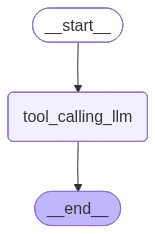

In [18]:
def tool_calling_llm(state:MessageState):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}


builder=StateGraph(MessageState)
builder.add_node("tool_calling_llm",tool_calling_llm)

builder.add_edge(START,"tool_calling_llm")
builder.add_edge("tool_calling_llm",END)

graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
messages=graph.invoke({"messages":HumanMessage(content="What is 2 minus 3")})
for m in messages["messages"]:
    m.pretty_print()
    
pprint(messages)

================================ Human Message =================================

What is 2 minus 3
================================== Ai Message ==================================
Tool Calls:
  add (62fpmf0qx)
 Call ID: 62fpmf0qx
  Args:
    a: 2
    b: -3
{'messages': [HumanMessage(content='What is 2 minus 3', additional_kwargs={}, response_metadata={}, id='27ed3c3f-a1a9-42ec-9034-caa92ca26e24'),
              AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking "What is 2 minus 3?" Let me think about how to approach this. The available tools are add and multiply functions. The question involves subtraction, though. Hmm, subtraction isn\'t directly listed as a tool. But wait, maybe I can use the add function with a negative number. Let me recall: subtracting 3 is the same as adding -3. So, 2 minus 3 would be 2 + (-3). The add function takes two integers, a and b. So if I set a to 2 and b to -3, that should work. Let me check if the add function can 

## Router Method in langgraph

In [25]:
from IPython.display import Image, display
from langgraph.graph import StateGraph,START,END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

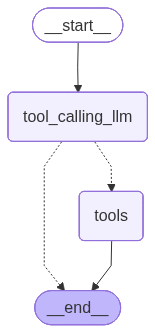

In [31]:
def tool_calling_llm(state:MessagesState):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}


builder=StateGraph(MessagesState)

builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode([add,multiply]))


builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)
builder.add_edge("tools",END)


graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
messages=[HumanMessage(content="Add 3 and 4 . Multiply the output by 2 and add 5")]
messages=graph.invoke({"messages":messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4 . Multiply the output by 2 and add 5
================================== Ai Message ==================================
Tool Calls:
  add (3f405kq4b)
 Call ID: 3f405kq4b
  Args:
    a: 3
    b: 4
  multiply (2padp8zr0)
 Call ID: 2padp8zr0
  Args:
    a: 7
    b: 2
  add (ac3e9rw22)
 Call ID: ac3e9rw22
  Args:
    a: 14
    b: 5
================================= Tool Message =================================
Name: add

7
================================= Tool Message =================================
Name: multiply

14
================================= Tool Message =================================
Name: add

19
